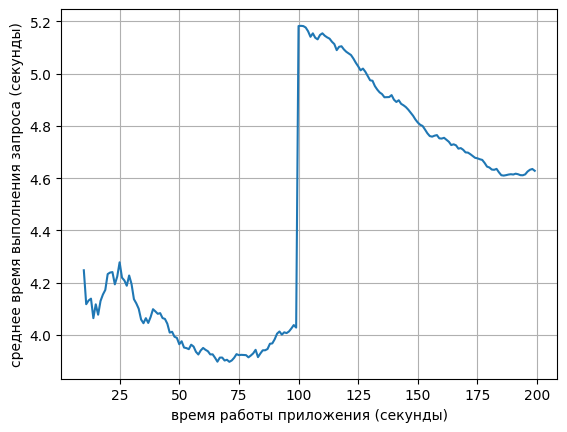

In [ ]:
from typing import List

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1702)

# моменты времени, в которые пришёл запрос
lst_t = []
# сколько обрабатывается каждый запрос
lst_latency = []

# смоделируем 200 запросов
for i in range(200):
    lst_t.append(i / 10)
    # добавим один плохой запрос
    # который по какой-то причине обрабатывался около 120 секунд
    if i == 100:
        lst_latency.append(np.random.normal() + 120)
        continue
    lst_latency.append(np.random.normal() + 4)


def metric_monitoring_mean(
    lst_latency: List[float],
) -> float:
    mean = np.mean(lst_latency)
    return mean


# считаем среднюю задержку, начиная с 10 секунды
lst_mean = []
t_range = range(10, len(lst_latency))
for i in t_range:
    lst_mean.append(metric_monitoring_mean(lst_latency[: i + 1]))


plt.plot(t_range, lst_mean)
plt.xlabel("время работы приложения (секунды)")
plt.ylabel("среднее время выполнения запроса (секунды)")
plt.grid()
plt.show()

In [ ]:
from typing import List

import numpy as np


def metric_monitoring_quantile(lst_latency: List[float], q: float) -> float:
    q_value = np.quantile(lst_latency, q)
    return q_value